In [2]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
import PIL.Image as Image
import torch 
import torchvision 
from torchvision import transforms
import pydicom


# Train Series Analysis

Analyze Train series to find subtle patterns

In [20]:
from numpy import floor


train_df = pd.read_csv("Datasets/rsna-knee/train.csv")
train_series_df = pd.read_csv("Datasets/rsna-knee/train_series.csv")
LABELS = [c for c in train_df.columns if c not in ["StudyInstanceUID", "Report"]]
print(f"Training Samples: {len(train_df)}")
print(f"Training Series: {len(train_series_df)} across {train_df['StudyInstanceUID'].nunique()} unique studies")
print(f"Each Study has: {len(train_series_df)/train_df['StudyInstanceUID'].nunique()} series per study on average")
print(f"Labels: {len(LABELS)} \n{LABELS}")

Training Samples: 4407
Training Series: 24371 across 4407 unique studies
Each Study has: 5.530065804402088 series per study on average
Labels: 12 
['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


Each Study has `5.53` series per study on average which means some studies dont have the normal 5 study or some studies have more need to look more into it

In [55]:
# Analyze the series data to find out the amount of slices each study has. 
# This is important because we want to make sure that we have enough slices for each study to train our model effectively. 
# We will filter out any studies that have less than 5 slices, as these may not provide enough information for the model 
# to learn from.
series_with_3_slices = train_series_df.groupby("StudyInstanceUID").filter(lambda x: len(x) <= 3)
series_with_3_slices_count = series_with_3_slices['StudyInstanceUID'].nunique()
series_with_4_slices = train_series_df.groupby("StudyInstanceUID").filter(lambda x: len(x) == 4)
series_with_4_slices_count = series_with_4_slices['StudyInstanceUID'].nunique()
series_with_5_slices = train_series_df.groupby("StudyInstanceUID").filter(lambda x: len(x) == 5)
series_with_5_slices_count = series_with_5_slices['StudyInstanceUID'].nunique()
series_with_6_slices = train_series_df.groupby("StudyInstanceUID").filter(lambda x: len(x) == 6)
series_with_6_slices_count = series_with_6_slices['StudyInstanceUID'].nunique()
series_with_more_than_7_slices = train_series_df.groupby("StudyInstanceUID").filter(lambda x: len(x) >= 7)
series_with_more_than_7_slices_count = series_with_more_than_7_slices['StudyInstanceUID'].nunique()
print(f"Studies with 3 slices: {series_with_3_slices_count}")
print(f"Studies with 4 slices: {series_with_4_slices_count}")
print(f"Studies with 5 slices: {series_with_5_slices_count}")
print(f"Studies with 6 slices: {series_with_6_slices_count}")
print(f"Studies with more than 7 slices: {series_with_more_than_7_slices_count}")

Studies with 3 slices: 1
Studies with 4 slices: 675
Studies with 5 slices: 2299
Studies with 6 slices: 698
Studies with more than 7 slices: 734


## Conclusion
### Unequal amount of slices in the training series
Unless the training series are made in such a way that the reports will eventually give an equal training sample this may 
be a problem to be tackled during generalization and training

--------------------------------------------------------------------------------------------------------------------------

# Language/Label Analysis

Analyze the language in the `Reports` in `Train.csv`. Find the frequency and language associated with the frequency.
Analyze the Labels as well

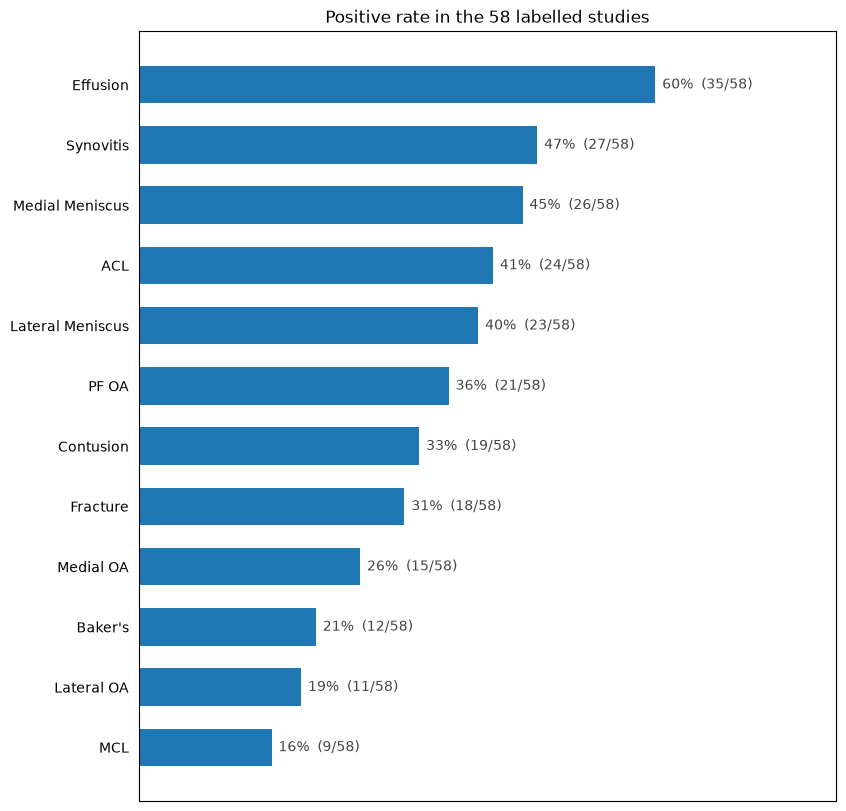

In [ ]:
# Check the number of labelled data and its language
cov = train_df[LABELS].notna().sum()
labelled_data = train_df[train_df[LABELS].notna().any(axis=1)]

rates = labelled_data[LABELS].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(rates.index, rates, height=0.62)
for k, v in rates.items():
    ax.text(v + .008, k, f'{v:.0%}  ({int(v * len(labelled_data))}/58)', va='center',
            fontsize=10, color='#444')
ax.set_xlim(0, rates.max() * 1.35)
ax.set_xticks([])
ax.tick_params(left=False)
ax.set_title('Positive rate in the 58 labelled studies')
plt.show()

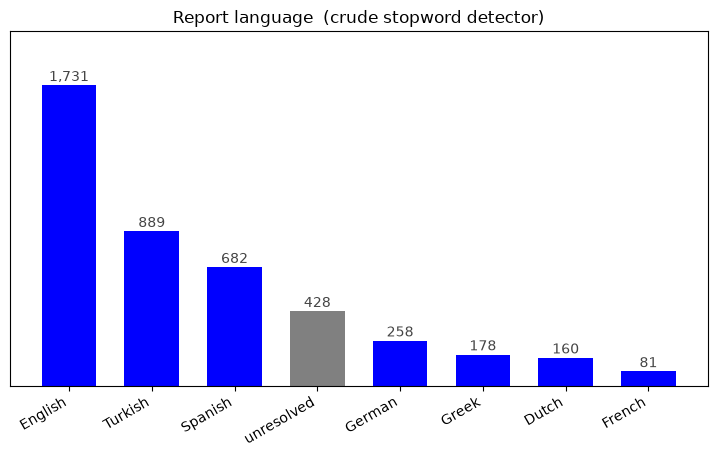

lang
English       1731
Turkish        889
Spanish        682
unresolved     428
German         258
Greek          178
Dutch          160
French          81


In [77]:
STOP = {
    'English':    [' the ', ' and ', ' with ', ' no ', 'knee', 'findings', 'impression'],
    'Spanish':    ['de la', ' del ', ' sin ', 'no hay', 'hallazgos', 'rodilla', 'menisco'],
    'Turkish':    [' ve ', 'diz ', 'bulgu', 'düzey', 'izlenmekte', 'menisk'],
    'German':     [' der ', ' und ', ' mit ', ' kein', 'knie', 'befund'],
    'Dutch':      ['van de', ' met ', 'geen ', 'knie ', 'bevindingen', 'meniscus'],
    'French':     [' de la ', ' avec ', ' sans ', 'genou', 'conclusion'],
    'Portuguese': [' da ', ' com ', ' sem ', 'joelho', 'achados'],
    'Greek':      ['ευρήματα', 'γόνατ', 'μηνίσκ', 'δεν ', 'εξέταση'],
}

def detect(text):
    t = ' ' + text.lower() + ' '
    score = {k: sum(t.count(w) for w in ws) for k, ws in STOP.items()}
    best = max(score, key=score.get)
    return best if score[best] > 1 else 'unresolved'

train_df['lang'] = train_df.Report.map(detect)
counts = train_df.lang.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.6))
col = ["GREY" if k == 'unresolved' else "BLUE" for k in counts.index]
ax.bar(counts.index, counts.values, color=col, width=.66)
for k, v in counts.items():
    ax.text(k, v + 25, f'{v:,}', ha='center', fontsize=10, color='#444')
ax.set_ylim(0, counts.max() * 1.18)
ax.set_yticks([])
ax.tick_params(left=False)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Report language  (crude stopword detector)')
plt.show()

print(counts.to_string())

In [78]:
1731 + 889 + 682 + 428 + 258 + 178 + 160 + 81

4407